In [3]:
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [4]:
movies = pd.read_csv('../../Data/transformed/movies_cleaned.csv')
movies

,movieId,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year
0,1,Toy Story (1995),0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1995
1,2,Jumanji (1995),0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1995
2,3,Grumpier Old Men (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1995
3,4,Waiting to Exhale (1995),0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1995
4,5,Father of the Bride Part II (1995),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3878,3948,Meet the Parents (2000),0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2000
3879,3949,Requiem for a Dream (2000),0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2000
3880,3950,Tigerland (2000),0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2000
3881,3951,Two Family House (2000),0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2000


## ACTIVAR ESTO PC CON POCA RAM

movies = movies.sample(10000)
movies.reset_index(inplace=True)
movies.drop(columns=['index'], inplace=True)
movies

In [5]:
def recommend_movies(movie_title, df, similarity_matrix, top_n=5):
    # Encontrar el índice de la película dada
    idx = df[df['title'] == movie_title].index[0]
    
    # Obtener similitudes con otras películas
    sim_scores = list(enumerate(similarity_matrix[idx]))
    
    # Ordenar por mayor similitud (excluyendo la propia película)
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    
    # Obtener los títulos recomendados
    recommended_indices = [i[0] for i in sim_scores]
    return df.loc[recommended_indices]
    #return df.loc[recommended_indices, ['title']]

In [6]:
# Normalizar el año
scaler = MinMaxScaler(feature_range=(-1, 1))
movies['year_scaled'] = scaler.fit_transform(movies[['year']])

In [7]:
genre_columns = movies.columns[2:-2]
X_genres = movies[genre_columns.tolist() + ['year_scaled']]

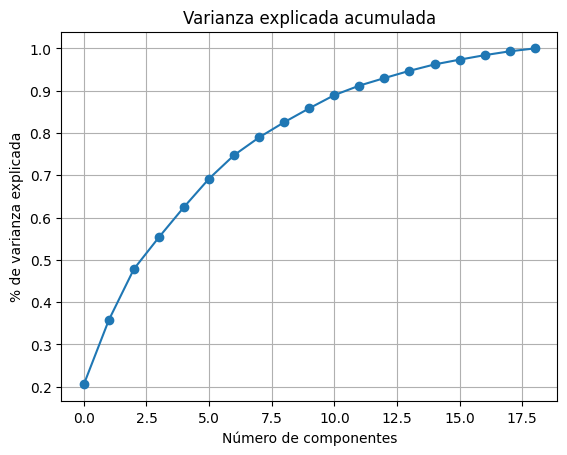

In [8]:
pca_full = PCA().fit(X_genres)
plt.plot(pca_full.explained_variance_ratio_.cumsum(), marker='o')
plt.title('Varianza explicada acumulada')
plt.xlabel('Número de componentes')
plt.ylabel('% de varianza explicada')
plt.grid()
plt.show()

In [9]:
componentes = 10

# Aplicamos PCA
pca = PCA(n_components=componentes)
X_genres_pca = pca.fit_transform(X_genres)

# Convertimos los resultados a un DataFrame
final_df = pd.DataFrame(X_genres_pca, columns=[f'genre_pca_{i+1}' for i in range(componentes)])

In [10]:
similarity_matrix = cosine_similarity(final_df)
similarity_matrix

array([[ 1.        ,  0.63384777,  0.32256734, ..., -0.3371469 ,
        -0.3371469 , -0.29757352],
       [ 0.63384777,  1.        , -0.09842932, ..., -0.12574596,
        -0.12574596, -0.16913868],
       [ 0.32256734, -0.09842932,  1.        , ..., -0.43256326,
        -0.43256326, -0.37947051],
       ...,
       [-0.3371469 , -0.12574596, -0.43256326, ...,  1.        ,
         1.        ,  0.55454916],
       [-0.3371469 , -0.12574596, -0.43256326, ...,  1.        ,
         1.        ,  0.55454916],
       [-0.29757352, -0.16913868, -0.37947051, ...,  0.55454916,
         0.55454916,  1.        ]], shape=(3883, 3883))

In [11]:
movie_test = movies.loc[0]
movie_test

movieId                       1
title          Toy Story (1995)
Action                        0
Adventure                     0
Animation                     1
Children's                    1
Comedy                        1
Crime                         0
Documentary                   0
Drama                         0
Fantasy                       0
Film-Noir                     0
Horror                        0
Musical                       0
Mystery                       0
Romance                       0
Sci-Fi                        0
Thriller                      0
War                           0
Western                       0
year                       1995
year_scaled            0.876543
Name: 0, dtype: object

In [12]:
recomendaciones = recommend_movies(movie_test['title'], movies, similarity_matrix)
recomendaciones

,movieId,title,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,...,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,year,year_scaled
1050,1064,Aladdin and the King of Thieves (1996),0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1996,0.901235
2285,2354,"Rugrats Movie, The (1998)",0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1998,0.950617
2286,2355,"Bug's Life, A (1998)",0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1998,0.950617
3045,3114,Toy Story 2 (1999),0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1999,0.975309
2073,2142,"American Tail: Fievel Goes West, An (1991)",0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1991,0.777778
